In [1]:
# ¿Cómo cambia un pronóstico SIR cuando, desde el inicio de la vacunación en Colombia, aprende diariamente de los casos observados?

# Los casos diagnosticados y los activos de 14 días son aproximaciones didácticas: no identifican la transmisión real ni demuestran el efecto causal de la vacunación.

import numpy as np
import pandas as pd

population = 50_372_424
vaccination_start = pd.Timestamp("2021-02-17")
analysis_end = pd.Timestamp("2021-06-30")
recovery_rate = 1 / 14


daily_cases = pd.read_csv("../data/colombia_daily_cases.csv.gz", compression="gzip", parse_dates=["date"])
observed = daily_cases.loc[daily_cases["date"].between("2020-03-06", analysis_end)].copy()
observed = observed.set_index("date").asfreq("D", fill_value=0).reset_index()
observed["active_cases_proxy"] = observed["daily_cases"].rolling(14, min_periods=1).sum()
observed["susceptible_proxy"] = population - observed["daily_cases"].cumsum()

# La tasa se infiere del cambio en los activos, para que la observación y la ecuación SIR hablen de la misma magnitud.
previous_active = observed["active_cases_proxy"].shift()
previous_susceptible = observed["susceptible_proxy"].shift()
required_infections = observed["active_cases_proxy"].diff() + recovery_rate * previous_active
observed["infection_rate"] = (
    population * required_infections / (previous_susceptible * previous_active)
).clip(0, 1)
observed["infection_rate"] = observed["infection_rate"].bfill()
observed.tail()

,date,daily_cases,active_cases_proxy,susceptible_proxy,infection_rate
477,2021-06-26,29327,408350.0,46130115,0.079575
478,2021-06-27,19481,408749.0,46110634,0.079064
479,2021-06-28,31468,421392.0,46079166,0.111820
480,2021-06-29,32103,419669.0,46047063,0.073614
481,2021-06-30,29199,416378.0,46017864,0.069560


In [2]:
# El corte coincide con el inicio de la vacunación; el tramo posterior permite comparar un pronóstico fijo con uno que se actualiza al recibir nueva información.

training = observed.loc[observed["date"] < vaccination_start].copy()
evaluation = observed.loc[observed["date"] >= vaccination_start].copy()

print(f"Entrenamiento: {training['date'].min():%Y-%m-%d} a {training['date'].max():%Y-%m-%d}")
print(f"Evaluación: {evaluation['date'].min():%Y-%m-%d} a {evaluation['date'].max():%Y-%m-%d}")

Entrenamiento: 2020-03-06 a 2021-02-16
Evaluación: 2021-02-17 a 2021-06-30


In [3]:
# El suavizado exponencial convierte las tasas observadas en una estimación que privilegia la evidencia reciente.

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

learning_rate = 0.2
rate_model = SimpleExpSmoothing(training["infection_rate"], initialization_method="estimated").fit(
    smoothing_level=learning_rate,
    optimized=False,
)
training["learned_infection_rate"] = rate_model.fittedvalues
static_rate = training["learned_infection_rate"].iloc[-1]

# Antes de conocer el caso de cada día, se conserva la tasa aprendida hasta ese momento.
learned_rate = static_rate
adaptive_rates = []
for observed_rate in evaluation["infection_rate"]:
    adaptive_rates.append(learned_rate)
    learned_rate = learning_rate * observed_rate + (1 - learning_rate) * learned_rate

evaluation["adaptive_infection_rate"] = adaptive_rates
evaluation["static_infection_rate"] = static_rate

evaluation[["date", "infection_rate", "adaptive_infection_rate", "static_infection_rate"]].head()

,date,infection_rate,adaptive_infection_rate,static_infection_rate
348,2021-02-17,0.033016,0.019333,0.019333
349,2021-02-18,0.030877,0.022069,0.019333
350,2021-02-19,0.042077,0.023831,0.019333
351,2021-02-20,0.055619,0.027480,0.019333
352,2021-02-21,0.050226,0.033108,0.019333


In [4]:
# El SIR usa la tasa disponible al inicio de cada día para producir un pronóstico comparable.

initial_infected = training["active_cases_proxy"].iloc[-1]
initial_susceptible = training["susceptible_proxy"].iloc[-1]
def simulate_sir(infection_rates):
    susceptible = initial_susceptible
    infected = initial_infected
    recovered = population - susceptible - infected
    records = []

    for date, infection_rate in zip(evaluation["date"], infection_rates):
        records.append(
            {
                "date": date,
                "infection_rate": infection_rate,
                "susceptible": susceptible,
                "infected": infected,
                "recovered": recovered,
                "required_beds": infected * 0.05,
            }
        )
        new_infections = infection_rate * infected * susceptible / population
        new_recoveries = recovery_rate * infected
        infected += new_infections - new_recoveries
        susceptible -= new_infections
        recovered += new_recoveries

    return pd.DataFrame(records)

In [5]:
# El modelo estático conserva la tasa previa a la vacunación; el adaptativo revisa esa tasa después de recibir cada observación diaria.

static_forecast = simulate_sir(evaluation["static_infection_rate"])
static_forecast["model"] = "SIR estático"
adaptive_forecast = simulate_sir(evaluation["adaptive_infection_rate"])
adaptive_forecast["model"] = "SIR adaptativo"

observed_evolution = evaluation[["date", "active_cases_proxy"]].rename(columns={"active_cases_proxy": "infected"})
observed_evolution["model"] = "Evolución observada (proxy)"
forecasts = pd.concat([static_forecast, adaptive_forecast, observed_evolution], ignore_index=True, sort=False)
forecasts.head()

,date,infection_rate,susceptible,infected,recovered,required_beds,model
0,2021-02-17,0.019333,4.814632e+07,69297.000000,2.156810e+06,3464.850000,SIR estático
1,2021-02-18,0.019333,4.814504e+07,65627.708446,2.161760e+06,3281.385422,SIR estático
2,2021-02-19,0.019333,4.814382e+07,62152.674442,2.166447e+06,3107.633722,SIR estático
3,2021-02-20,0.019333,4.814268e+07,58861.617043,2.170887e+06,2943.080852,SIR estático
4,2021-02-21,0.019333,4.814159e+07,55744.799070,2.175091e+06,2787.239954,SIR estático


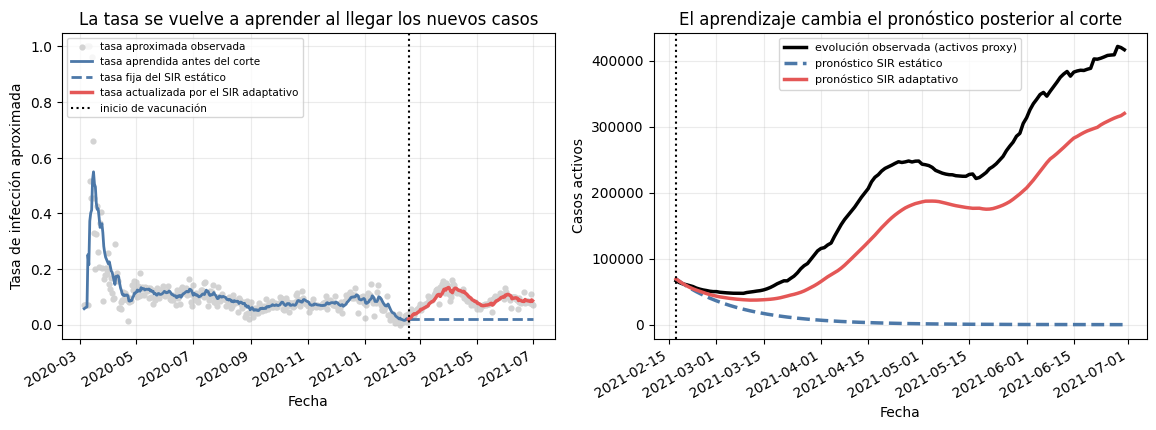

In [6]:
# La figura separa el aprendizaje de la tasa del efecto que esa actualización tiene sobre el pronóstico de casos activos.

import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].scatter(
    observed["date"],
    observed["infection_rate"],
    color="lightgray",
    s=12,
    label="tasa aproximada observada",
)
axes[0].plot(
    training["date"],
    training["learned_infection_rate"],
    color="#4c78a8",
    linewidth=2,
    label="tasa aprendida antes del corte",
)
axes[0].plot(
    evaluation["date"],
    evaluation["static_infection_rate"],
    color="#4c78a8",
    linestyle="--",
    linewidth=2,
    label="tasa fija del SIR estático",
)
axes[0].plot(
    evaluation["date"],
    evaluation["adaptive_infection_rate"],
    color="#e45756",
    linewidth=2.5,
    label="tasa actualizada por el SIR adaptativo",
)
axes[0].axvline(vaccination_start, color="black", linestyle=":", linewidth=1.5, label="inicio de vacunación")
axes[0].set(
    title="La tasa se vuelve a aprender al llegar los nuevos casos",
    xlabel="Fecha",
    ylabel="Tasa de infección aproximada",
)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=7.5, loc="upper left")

axes[1].plot(
    observed_evolution["date"],
    observed_evolution["infected"],
    color="black",
    linewidth=2.5,
    label="evolución observada (activos proxy)",
)
axes[1].plot(
    static_forecast["date"],
    static_forecast["infected"],
    color="#4c78a8",
    linestyle="--",
    linewidth=2.5,
    label="pronóstico SIR estático",
)
axes[1].plot(
    adaptive_forecast["date"],
    adaptive_forecast["infected"],
    color="#e45756",
    linewidth=2.5,
    label="pronóstico SIR adaptativo",
)
axes[1].axvline(vaccination_start, color="black", linestyle=":", linewidth=1.5)
axes[1].set(
    title="El aprendizaje cambia el pronóstico posterior al corte",
    xlabel="Fecha",
    ylabel="Casos activos",
)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
figure.autofmt_xdate()
plt.show()

In [7]:
# Los artefactos permiten auditar las tasas usadas, los pronósticos y el supuesto que hace posible la comparación.

from pathlib import Path
import json

submission_dir = Path("../submission")
rate_history = pd.concat(
    [
        training[["date", "infection_rate", "learned_infection_rate"]].assign(period="antes de vacunación"),
        evaluation[["date", "infection_rate", "adaptive_infection_rate", "static_infection_rate"]].assign(period="después de vacunación"),
    ],
    ignore_index=True,
)
rate_history.to_csv(submission_dir / "infection_rate_forecast.csv", index=False)
forecasts.to_csv(submission_dir / "forecasts.csv", index=False)

scenario_peaks = pd.DataFrame(
    [
        {
            "model": name,
            "peak_date": group.loc[group["infected"].idxmax(), "date"],
            "peak_infected": group["infected"].max(),
        }
        for name, group in forecasts.groupby("model")
    ]
)
scenario_peaks.to_csv(submission_dir / "scenario_peaks.csv", index=False)

assumptions = {
    "vaccination_start": vaccination_start.strftime("%Y-%m-%d"),
    "evaluation_end": analysis_end.strftime("%Y-%m-%d"),
    "learning_rate": learning_rate,
    "static_rate": static_rate,
    "active_cases_proxy": "rolling 14-day sum of reported diagnoses",
    "limitation": "The comparison illustrates online adaptation; it does not attribute changes to vaccination or estimate true transmission.",
}
(submission_dir / "model_assumptions.json").write_text(json.dumps(assumptions, indent=2), encoding="utf-8")
figure.savefig(submission_dir / "adaptive_evolution.png", dpi=150, bbox_inches="tight")
